In [31]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
import spikeinterface.extractors as se
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
from spikeinterface.extractors import SpikeGadgetsRecordingExtractor


In [43]:
d13_data = r"E:\sprite32\subj_5_13_baseline_d13_20250526_143515.rec\subj_5_13_baseline_d13_20250526_143515_merged.rec"
ecg_resp = se.read_spikegadgets(d13_data, stream_id = 'trodes')
print(ecg_resp)

SpikeGadgetsRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 12,143,682 samples 
                                607.18s (10.12 minutes) - int16 dtype - 741.19 MiB
  file_path: E:\sprite32\subj_5_13_baseline_d13_20250526_143515.rec\subj_5_13_baseline_d13_20250526_143515_merged.rec


In [44]:
import os
import warnings
import re
from collections import defaultdict
import pathlib
import numpy as np
import subprocess
import glob

def parse_fields(field_str):
    """
    Parses a string of fields into a numpy data type object.

    The input string should be formatted as '<fieldname num*type>' or
    '<fieldname type>'. This function parses the string, extracts the field
    names and data types, and creates a numpy data type object which can be
    used to read data from a binary file.

    Args:
        field_str (str): The string specifying the fields.

    Returns:
        np.dtype: A numpy data type object that describes the structure of
                  the data.

    Raises:
        SystemExit: If the provided field type is not a valid numpy data type.
    """

    # Clean up the string and split it into components
    components = re.split("\s", re.sub(r"\>\<|\>|\<", " ", field_str).strip())

    dtype_spec = []  # Will hold tuples to specify the numpy data type

    # Iterate over pairs of components (field name and type)
    for i in range(0, len(components), 2):
        field_name = components[i]

        # Default values
        repeat_count = 1
        field_type_str = "uint32"

        # If the field type string contains a '*', it indicates a repeat count
        if "*" in components[i + 1]:
            split_types = re.split("\*", components[i + 1])
            # Handle both 'num*type' and 'type*num'
            field_type_str = split_types[split_types[0].isdigit()]
            repeat_count = int(split_types[split_types[1].isdigit()])
        else:
            field_type_str = components[i + 1]

        # Convert the field type string to an actual numpy data type
        try:
            field_type = getattr(np, field_type_str)
        except AttributeError:
            print(f"{field_type_str} is not a valid field type.")
            exit(1)
        else:
            dtype_spec.append((str(field_name), field_type, repeat_count))

    return np.dtype(dtype_spec)


def read_trodes_extracted_data_file(filename):
    """
    Reads the content of a Trodes extracted data file.

    This function opens a Trodes file, reads the settings, parses them into a dictionary,
    and then reads the remaining data in the file as a numpy array according to the
    data types specified in the settings. If the settings block does not start correctly,
    it raises an Exception.

    Args:
        filename (str): The path to the Trodes file to be read.

    Returns:
        dict: A dictionary where keys are settings field names and values are the
              corresponding setting values. The actual data from the file is stored
              under the 'data' key as a numpy array.

    Raises:
        Exception: If the settings block in the file does not start with '<Start settings>'.
    """
    with open(filename, "rb") as f:
        # The first line of the file should start the settings block
        if f.readline().decode("ascii").strip() != "<Start settings>":
            raise Exception("Settings format not supported")

        # Flag indicating we're reading the settings block
        fields = True
        # Dictionary to hold the settings fields and values
        fields_text = {}

        # Iterate over the lines in the file
        for line in f:
            # If we're still reading the settings block
            if fields:
                line = line.decode("ascii").strip()
                # If we've not reached the end of the settings block, continue reading fields
                if line != "<End settings>":
                    key, value = line.split(": ")
                    fields_text.update({key.lower(): value})
                # If we've reached the end of the settings block, stop reading fields
                else:
                    fields = False
                    # Parse the 'fields' setting to get the data type
                    dt = parse_fields(fields_text["fields"])
                    fields_text["data"] = np.zeros([1], dtype=dt)
                    break

        # Read the remaining data from the file using the parsed data type
        dt = parse_fields(fields_text["fields"])
        data = np.fromfile(f, dt)
        fields_text.update({"data": data})
        fields_text.update({"filename": os.path.basename(filename)})
        return fields_text


def organize_single_trodes_export(dir_path, skip_raw_group0=True):
    """
    Organizes Trodes data files in a given directory. The data is stored in a dictionary.
    The key is the penultimate (second to last) part of the file name (i.e., the part before the last dot in the file name).
    The values in the dictionary are the parsed data from the Trodes files.

    Args:
        dir_path (str): The path to the directory containing the Trodes files.
        skip_raw_group0(bool): To skip the "raw_group0" file which contains the raw signal which uses a lot of memory
    Returns:
        dict: A dictionary with organized Trodes file data.
    """
    # Initialize dictionary to store results
    result = {}

    # Iterate over all files in the directory
    for file_name in os.listdir(dir_path):

        if skip_raw_group0 and "raw_group0" in file_name:
            continue
        # Attempt to parse each file and store the data in the dictionary
        try:
            # Extract second to last part of the file name
            sub_dir_name = file_name.rsplit(".", 2)[-2]
            # Parse Trodes file and store the data
            result[sub_dir_name] = read_trodes_extracted_data_file(os.path.join(dir_path, file_name))

        # Skip files that cause errors during parsing
        except Exception as e:
            print(f"Skipping file {file_name} due to error: {e}")
            continue

    return result

def organize_all_trodes_export(dir_path):
    """
    Organize Trodes files in subdirectories based on prefix and suffix of the subdirectory.
    The function creates a dictionary with subdirectory prefix and suffix as keys,
    and the output of `organize_trodes_files_by_suffix` as values.

    Args:
        dir_path (str): Path of the directory to process.

    Returns:
        dict: Nested dictionary with keys as subdirectory prefix and suffix and values
        containing data obtained from the `organize_trodes_files_by_suffix` function.
    """
    result = defaultdict(dict)

    for sub_dir_name in os.listdir(dir_path):
        # Construct the full path to the subdirectory
        sub_dir_path = os.path.join(dir_path, sub_dir_name)
        # Process only if it's a directory
        if os.path.isdir(sub_dir_path):
            try:
                # Split the subdirectory name by dots to extract prefix and suffix
                sub_dir_name_parts = sub_dir_name.split(".")
                sub_dir_name_prefix = sub_dir_name_parts[0]
                sub_dir_name_suffix = sub_dir_name_parts[-1]
                # Organize the Trodes files in the subdirectory and store the results
                result[sub_dir_name_prefix][sub_dir_name_suffix] = organize_single_trodes_export(sub_dir_path)
            except Exception as e:
                print(f"Error processing subdirectory {sub_dir_path}: {e}")
                continue

    return result

results = organize_all_trodes_export(r"E:\sprite32\subj_5_13_baseline_d13_20250526_143515.rec")

Skipping file subj_5_13_baseline_d13_20250526_143515_merged.timestampoffset.txt due to error: Settings format not supported


In [ ]:
results['subj_5_13_baseline_d13_20250526_143515_merged']['analog']['analog_Controller_Ain1']['byte_order']



'little endian'

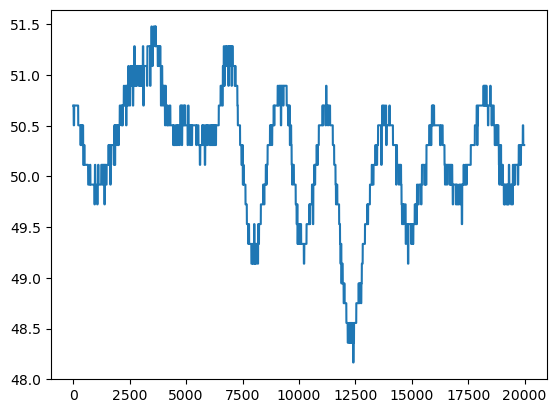

In [84]:
snippet = results['subj_5_13_baseline_d13_20250526_143515_merged']['analog']['analog_Controller_Ain1']['data'][20:20000]
snippet= snippet['voltage'].astype(float)

plt.plot(snippet *0.195)



In [32]:
datapath = r"E:\sprite32\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec"
#se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'trodes')
print(recording)


SpikeGadgetsRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 12,217,805 samples 
                                610.89s (10.18 minutes) - int16 dtype - 745.72 MiB
  file_path: E:\sprite32\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec


In [33]:
# Check the available attributes and methods of the recording object
print(dir(recording))

# Or print the entire object to inspect its contents
print(recording)

['NeoRawIOClass', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_annotations', '_channel_slice', '_check_segment_index', '_dtype', '_extra_metadata_from_folder', '_extra_metadata_to_folder', '_frame_slice', '_get_file_path', '_kwargs', '_main_annotations', '_main_features', '_main_ids', '_main_properties', '_preferred_mp_context', '_properties', '_recording_segments', '_remove_channels', '_sampling_frequency', '_save', '_select_segments', '_serializability', '_skip_properties', 'add_recording_segment', 'annotate', 'astype', 'binary_compatible_with', 'block_index', 'build_stream_id_to_sampling_frequency_dict', 'build_stream_id_to_t_start_dict', 'build_stream_name_to_stream_id_dict', 'channel_i

In [34]:
# Check the channel IDs, which might provide insight into the stream configuration
print(recording.channel_ids)

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '30' '31']


In [35]:
elec_noise_freq=60
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3130311/ paper suggested these min and max cut offs
min_freq=30
max_freq=1000
resample_rate=1000

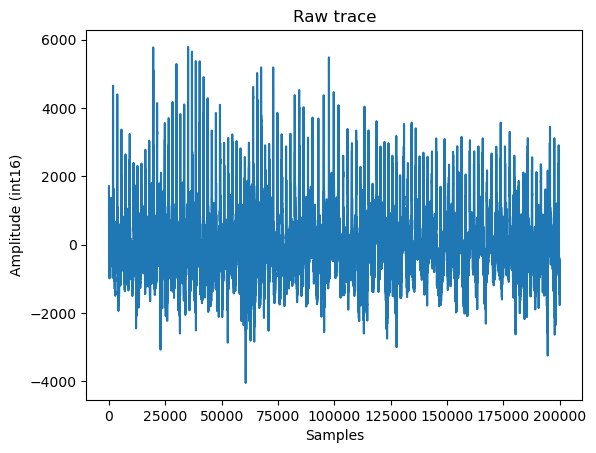

In [36]:
# Extract traces from the first segment
# For example, get the first 10 seconds of data from channel 0
sampling_rate = recording.get_sampling_frequency()
duration_sec = 10
num_samples = int(duration_sec * sampling_rate)

traces = recording.get_traces(start_frame=0, end_frame=num_samples, channel_ids=['21'])
plt.plot(traces)
plt.title("Raw trace")
plt.xlabel("Samples")
plt.ylabel("Amplitude (int16)")
plt.show()


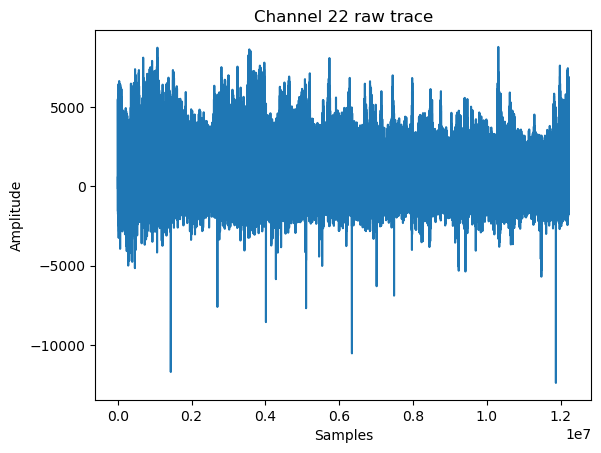

In [37]:
import matplotlib.pyplot as plt

# Get traces (shape: samples x channels)
traces = recording.get_traces()

# Check sampling frequency
fs = recording.get_sampling_frequency()

# Plot a channel (e.g., channel '26')
channel_id = '22'  # as a string since channel IDs are strings
channel_index = recording.id_to_index(channel_id)  # convert to integer index

plt.plot(traces[:, channel_index])
plt.title(f"Channel {channel_id} raw trace")
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()


In [38]:
# Notch filter to remove 60 Hz noise
recording_filtered = sp.notch_filter(recording, freq=60)

# Bandpass filter 30-1000 Hz
recording_filtered = sp.bandpass_filter(recording_filtered, freq_min=30, freq_max=1000)


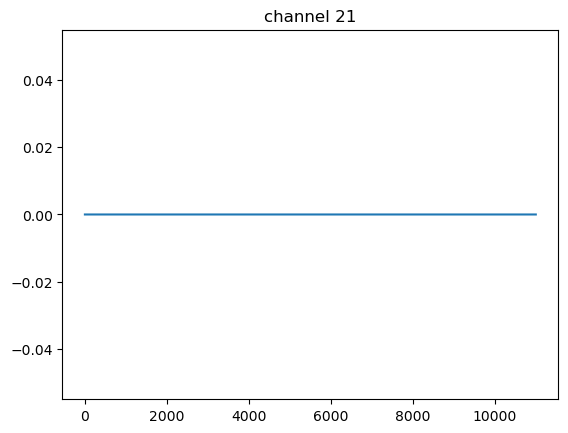

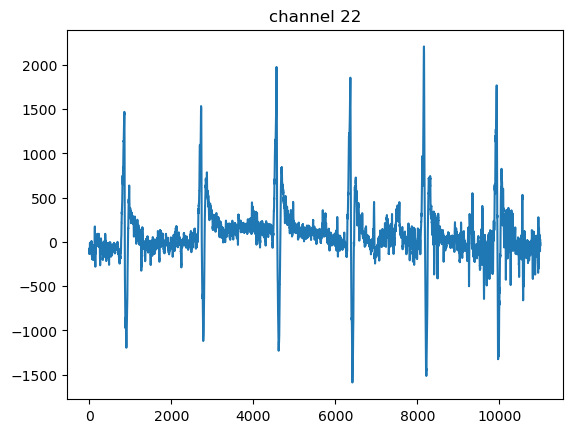

In [39]:
for i in [21,22]:    
    ref_traces=traces[:,i]-traces[:,21]
    plt.plot(ref_traces[1000:12000])
    plt.title(f'channel {i}')
    plt.show()

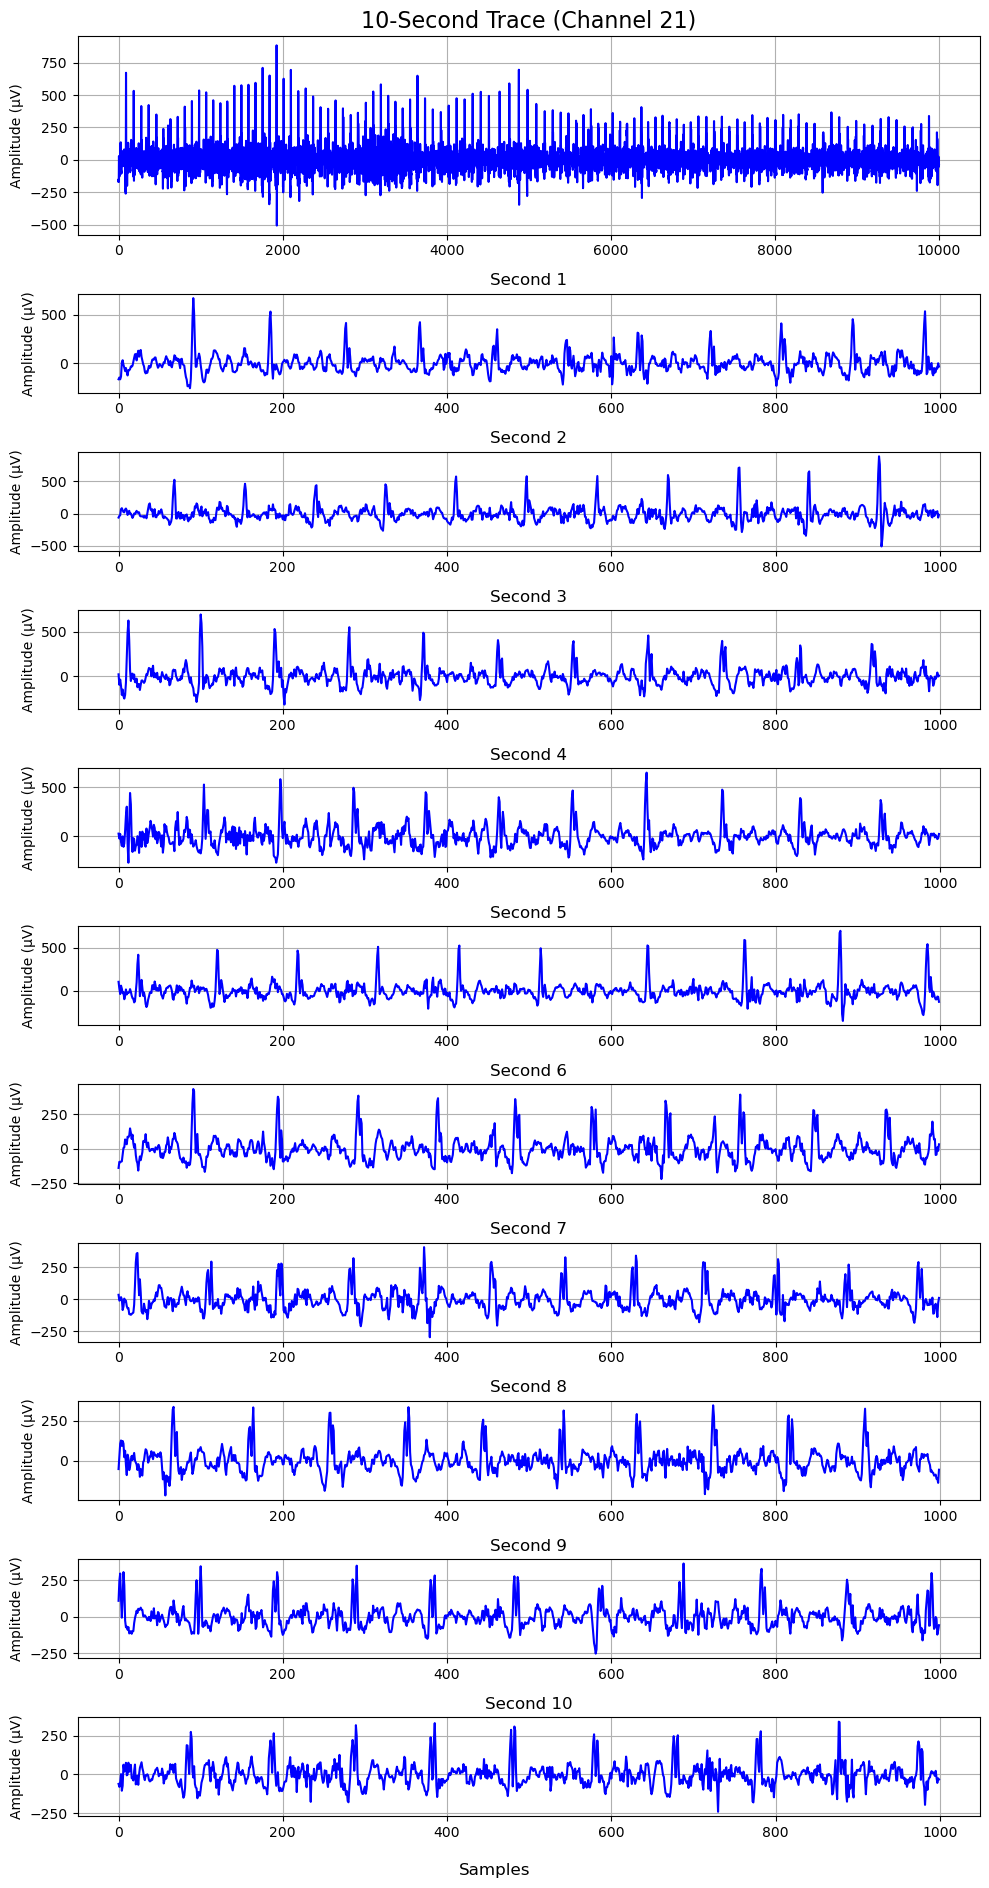

In [40]:
# Parameters
elec_noise_freq = 60
min_freq = 30
max_freq = 1000
resample_rate = 1000
datapath = r"E:\sprite32\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec"
ref_channel = 22
traces_bipolar = traces - traces[:, ref_channel, np.newaxis]

# Load and preprocess the recording
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)
traces = recording.get_traces()

# Define chunking parameters
samples_per_second = resample_rate
samples_per_10sec = 10 * samples_per_second
samples_per_1sec = samples_per_second

# Select the start of the chunk (e.g., first 10 seconds of recording)
start_idx = 0
end_idx = start_idx + samples_per_10sec

# Extract the 10-second trace for a specific channel (e.g., channel 26)
channel = 21
ten_sec_trace = traces[start_idx:end_idx, channel]

# Convert data to microvolts if necessary
# Assuming the data is in its raw format and needs scaling
scaling_factor = 0.195  # Example: conversion from ADC units to µV
ten_sec_trace = ten_sec_trace * scaling_factor

# Create a figure with one large plot for the 10-second trace and subplots for 1-second chunks
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)  # 1 large plot + 10 smaller plots

# Plot the full 10-second trace at the top
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ten_sec_trace, color='b')
ax1.set_title(f"10-Second Trace (Channel {channel})", fontsize=16)
ax1.set_ylabel("Amplitude (µV)")
ax1.grid()

# Plot the 1-second subplots
for i in range(10):
    chunk_start = i * samples_per_1sec
    chunk_end = chunk_start + samples_per_1sec
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(ten_sec_trace[chunk_start:chunk_end], color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid()

# Add a common x-axis label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp

# --- Parameters ---
elec_noise_freq = 60          # Notch out 60 Hz line noise
min_freq = 30                 # Bandpass lower bound
max_freq = 1000               # Bandpass upper bound
resample_rate = 1000          # Resample to 1 kHz
ref_channel = 22              # Reference channel for bipolar subtraction (if needed)
channel = 21                  # Channel to visualize
scaling_factor = 0.195        # Convert from ADC to microvolts (if needed)

# --- Load and preprocess recording ---
datapath = r"D:\EKG_resp_spikegadgets\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec"
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)

# Get traces and convert to microvolts
traces = recording.get_traces()
trace = traces[:, channel] * scaling_factor

# --- Define chunking ---
samples_per_second = resample_rate
total_seconds = trace.shape[0] // samples_per_second

# --- Loop through each second and plot ---
for sec in range(total_seconds):
    start_idx = sec * samples_per_second
    end_idx = start_idx + samples_per_second
    chunk = trace[start_idx:end_idx]

    plt.figure(figsize=(10, 3))
    plt.plot(chunk, color='b')
    plt.title(f"Channel {channel} - Second {sec+1}")
    plt.xlabel("Samples (1 kHz)")
    plt.ylabel("Amplitude (µV)")
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Optional: pause or save the plot
    # input("Press Enter to continue...")  # Uncomment for manual stepping
    # plt.savefig(f"channel_{channel}_sec_{sec+1}.png")  # Save plots instead of showing


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\EKG_resp_spikegadgets\\sub_5_13_baseline_20250523_105046.rec\\sub_5_13_baseline_20250523_105046_merged.rec'

In [ ]:
import spikeinterface.extractors as se

datapath = r"D:\EKG_resp_spikegadgets\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec"

# Load the recording extractor
recording = se.read_spikegadgets(datapath)

# List available stream IDs
print("Available stream IDs:")
print(recording.get_property("available_streams"))



Available stream IDs:
None


In [ ]:
import spikeinterface.extractors as se

datapath = r"D:\EKG_resp_spikegadgets\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec"

# Load the default stream
recording = se.read_spikegadgets(datapath)

# Get number of channels and their IDs
print("Number of channels:", recording.get_num_channels())
print("Channel IDs:", recording.get_channel_ids())


Number of channels: 32
Channel IDs: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '30' '31']


In [ ]:
import neo

reader = neo.rawio.SpikeGadgetsRawIO(filename=datapath)
reader.parse_header()

# List available stream names
print("Signal streams:")
print(reader.header['signal_streams'])

# List channel info per stream
print("\nSignal channels:")
print(reader.header['signal_channels'])

Signal streams:
[('trodes', 'trodes', '')]

Signal channels:
[('hwChan0', '0', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan1', '1', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan2', '2', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan3', '3', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan4', '4', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan5', '5', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan6', '6', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan7', '7', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan8', '8', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan9', '9', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan10', '10', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan11', '11', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan12', '12', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwChan13', '13', 20000., 'int16', 'uV', 0.195, 0., 'trodes', '')
 ('hwCh

In [ ]:
recording_ephys = se.read_spikegadgets(datapath, stream_id='trodes')
print("Ephys:", recording_ephys.get_num_channels(), "channels")




Ephys: 32 channels


In [ ]:
import spikeinterface.extractors as se

datapath = r"D:\EKG_resp_spikegadgets\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec"
# Load recording without specifying stream_id first
recording = se.read_spikegadgets(datapath)

print("Channels:", recording.get_channel_ids())
print("Number of channels:", recording.get_num_channels())


Channels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '30' '31']
Number of channels: 32


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

rec_folder = r"D:\EKG_resp_spikegadgets\sub_5_13_baseline_20250523_105046.rec\sub_5_13_baseline_20250523_105046_merged.rec"
analog_file = os.path.join(rec_folder, "Controller_Ain1.dat")

# The data is usually int16, but check metadata for confirmation
analog_data = np.fromfile(analog_file, dtype=np.int16)

plt.plot(analog_data[:30000])
plt.title("Respiratory Analog Signal (Controller_Ain1)")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (int16)")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\EKG_resp_spikegadgets\\sub_5_13_baseline_20250523_105046.rec\\sub_5_13_baseline_20250523_105046_merged.rec\\Controller_Ain1.dat'

In [ ]:
import os

rec_folder = r"D:\EKG_resp_spikegadgets\sub_5_13_baseline_20250523_105046_merged.rec"

files = os.listdir(rec_folder)
print(files)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\EKG_resp_spikegadgets\\sub_5_13_baseline_20250523_105046_merged.rec'